<a href="https://colab.research.google.com/github/borisbolliet/agents_lab_2026/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```
!pip install langchain -q
!pip install langgraph -q
!pip install langchain-google-genai -q
!pip install python-dotenv -q
```

In [1]:
try:
    from google.colab import userdata
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
except ImportError:
    from dotenv import load_dotenv
    import os
    load_dotenv()
    GOOGLE_API_KEY = os.environ['GOOGLE_API_KEY']

# Lab 3 — Propose ↔ Critique with Context Variable Injection and Specialist Formatters

In Labs 1 and 2 we used a single agent. In Lab 3 we build a **two-agent loop** with **typed outputs**:

- `idea_maker` proposes a single idea (free-form prose).
- `format_idea` converts that prose into a Pydantic `Idea`.
- `idea_hater` critiques the typed idea (free-form prose).
- `format_critique` converts that critique into a Pydantic `Critique`.
- Loop for `N` rounds, then stop.

Three new techniques on top of what Lab 2 taught:

1. **Context variable injection.** Variables like the research topic and the number of rounds are *not* hard-coded into prompts and *not* baked into the graph. They are passed at invocation time through a typed `context_schema`, and each node reads them via `Runtime[ContextSchema]`. Same graph → many runs with different contexts.

2. **Multi-model orchestration.** A cheap, fast model **proposes** (high throughput), an expensive, careful model **critiques** (sharper reasoning). This mirrors the `idea_maker` / `idea_hater` setup in [cmbagent](https://github.com/CMBAgents/cmbagent), originally in AG2 — here we rebuild it in LangGraph.

3. **Specialist formatter nodes.** Instead of forcing the generator to think *and* format simultaneously (which degrades reasoning quality and is brittle), we add a tiny downstream node that takes the generator's free-form output and converts it to a Pydantic model via `with_structured_output`. This is cmbagent's `*_response_evaluator` pattern.

Reference: [LangGraph overview](https://docs.langchain.com/oss/python/langgraph/overview).

## Two models — propose vs critique

We expose the model IDs as constants so you can swap them without touching the rest of the notebook.

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

PROPOSE_MODEL  = "gemini-3.1-flash-lite-preview"   # cheap, fast → idea_maker
CRITIQUE_MODEL = "gemini-3-pro-preview"            # careful, sharp → idea_hater
FORMAT_MODEL   = "gemini-3.1-flash-lite-preview"   # cheap, deterministic → formatter

proposer = ChatGoogleGenerativeAI(
    model=PROPOSE_MODEL,
    temperature=1.0,
    thinking_level="low",
    google_api_key=GOOGLE_API_KEY,
)

critic = ChatGoogleGenerativeAI(
    model=CRITIQUE_MODEL,
    temperature=0.4,
    thinking_level="high",
    google_api_key=GOOGLE_API_KEY,
)

formatter_llm = ChatGoogleGenerativeAI(
    model=FORMAT_MODEL,
    temperature=0.0,
    google_api_key=GOOGLE_API_KEY,
)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


## Context schema — what we inject at invocation time

Context variables travel with the **run**, not the graph. We declare a dataclass describing per-run knobs and LangGraph hands it to every node as `runtime.context`. This is the LangGraph-native answer to cmbagent's YAML templating (`{improved_main_task}`, `{final_plan}`, …).

In [3]:
from dataclasses import dataclass

@dataclass
class IdeaContext:
    research_topic: str
    num_rounds: int = 2
    constraints: str = "No external data sources. Ideas must be testable."

## Typed outputs with Pydantic

We define **two response schemas** — one for what the maker produces, one for what the hater produces. These are the contracts the formatter nodes will enforce. Downstream code (printing, scoring, feeding into the next iteration) gets typed objects, not blobs of text.

In [4]:
from pydantic import BaseModel, Field

class Idea(BaseModel):
    """A single concrete research idea."""
    title: str = Field(description="One-line title.")
    summary: str = Field(description="2-3 sentences describing the idea.")
    method: str = Field(description="How you would test or implement it.")
    expected_outcome: str = Field(description="What you would measure or produce.")

class Critique(BaseModel):
    """Structured critique of a single idea."""
    feasibility: str = Field(description="Concrete feasibility issues, if any.")
    novelty: str = Field(description="Whether the idea is novel and why or why not.")
    constraints_respected: bool = Field(description="True if the idea respects the constraints.")
    fixes: list[str] = Field(description="Concrete fixes to make on the next revision.")

## Schema-driven prompts + the specialist formatter

Two helpers in this section, both built around the Pydantic schemas:

1. **`schema_field_brief(schema)`** — turns a Pydantic model into a one-line-per-field description suitable for dropping into a *generator's* system prompt. The generator still writes free-form prose, but it knows exactly what fields the downstream formatter will try to populate. **The schema becomes the single source of truth** — add a field to `Idea`, and both the maker's prompt and the formatter pick it up automatically.

2. **`make_formatter(schema, ...)`** — a factory that builds a downstream formatter node bound to a particular schema and input/output state fields. The formatter is deliberately small, deterministic (temperature 0), and does one thing. We instantiate it twice — once for `Idea`, once for `Critique`. This is cmbagent's `*_response_evaluator` pattern.

In [5]:
from langchain_core.messages import HumanMessage, SystemMessage

def _type_name(ann) -> str:
    # str(int) -> "<class 'int'>", str(list[str]) -> "list[str]" — clean both.
    s = str(ann).replace("typing.", "")
    if s.startswith("<class '") and s.endswith("'>"):
        return s[len("<class '"):-len("'>")]
    return s

def schema_field_brief(schema) -> str:
    """Render a Pydantic schema as a bullet list of fields + descriptions.

    Used inside *generator* prompts so the writer knows what to cover, while
    still producing free-form prose (no JSON)."""
    lines = []
    for name, field in schema.model_fields.items():
        t = _type_name(field.annotation)
        desc = field.description or ""
        lines.append(f"- {name} ({t}): {desc}")
    return "\n".join(lines)

def make_formatter(schema, input_field: str, output_field: str, tag: str):
    """Build a node that converts state[input_field] (str) into a `schema` instance
    and writes it to state[output_field]. Tags the LLM call so the logger
    can attribute it."""
    structured = formatter_llm.with_structured_output(schema)
    sys = SystemMessage(
        f"You are a formatter. Convert the user's text into a {schema.__name__} "
        f"object. Preserve all substantive content. Do not invent new facts. "
        f"If a field is not explicitly stated, infer it conservatively from context."
    )

    def formatter(state, runtime):
        raw = state[input_field]
        obj = structured.invoke([sys, HumanMessage(raw)], config={"tags": [tag]})
        return {output_field: obj}
    return formatter

## State schema — what flows between nodes

State is the *mutable* part of the run: it changes as nodes execute and gets handed from node to node. We track:

- `raw_idea` / `raw_critique` — the generator's free-form output (transient, used as input to the formatter)
- `current_idea` — typed `Idea`, written by `format_idea`
- `current_critique` — typed `Critique`, written by `format_critique`, or `None` on round 1
- `round` — counter, incremented by the maker

No `history` field. We capture the run trace **outside** the state, by streaming each LLM response to a JSON Lines log file via a LangChain callback (next section). That's the same pattern an autonomous backend would use.

In [6]:
from typing import TypedDict, Optional

class IdeaState(TypedDict, total=False):
    raw_idea: str
    current_idea: Idea
    raw_critique: str
    current_critique: Optional[Critique]
    round: int

## `idea_maker` node

The proposer. Free-form prose only — no JSON. But its system prompt is **derived from the `Idea` schema** via `schema_field_brief(Idea)`, so it knows exactly what fields the downstream formatter will populate. Add a field to `Idea` and the proposer's prompt updates automatically.

Reads `runtime.context` for the topic and constraints, and `state["current_idea"]` / `state["current_critique"]` (typed) from previous rounds.

On the **first round** (`current_critique is None`) it produces a fresh idea. On **subsequent rounds** it revises in light of the critic's feedback, which it sees as a structured Pydantic dump.

In [7]:
from langgraph.runtime import Runtime

MAKER_SYSTEM = (
    "You are idea_maker. You generate one concrete, testable research idea.\n"
    "Write naturally in prose. A downstream specialist will extract these fields "
    "from your response, so make sure every field has enough material:\n\n"
    f"{schema_field_brief(Idea)}"
)

def idea_maker(state: IdeaState, runtime: Runtime[IdeaContext]) -> IdeaState:
    ctx = runtime.context
    round_n = state.get("round", 0) + 1
    critique = state.get("current_critique")

    if critique is None:
        user = (
            f"Research topic:\n{ctx.research_topic}\n\n"
            f"Constraints:\n{ctx.constraints}\n\n"
            f"Propose a single idea."
        )
    else:
        prev = state["current_idea"]
        user = (
            f"Research topic:\n{ctx.research_topic}\n\n"
            f"Constraints:\n{ctx.constraints}\n\n"
            f"Your previous idea:\n{prev.model_dump_json(indent=2)}\n\n"
            f"idea_hater's critique:\n{critique.model_dump_json(indent=2)}\n\n"
            f"Revise. Address every fix the critic listed. Return one revised idea."
        )

    msg = proposer.invoke(
        [SystemMessage(MAKER_SYSTEM), HumanMessage(user)],
        config={"tags": ["idea_maker"]},
    )
    return {"raw_idea": msg.text, "round": round_n}

/Users/boris/pyvenvs/py312-agents-lab-2026/lib/python3.12/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## `idea_hater` node

The critic. Also free-form prose, with its system prompt derived from `Critique` via the same `schema_field_brief` helper. It sees the latest typed `Idea` (not the raw text) — so it always critiques the canonical version the formatter produced.

In [8]:
HATER_SYSTEM = (
    "You are idea_hater. You critique a single research idea hard but fairly.\n"
    "Write naturally in prose. A downstream specialist will extract these fields "
    "from your response, so make sure every field has enough material:\n\n"
    f"{schema_field_brief(Critique)}"
)

def idea_hater(state: IdeaState, runtime: Runtime[IdeaContext]) -> IdeaState:
    ctx = runtime.context
    idea = state["current_idea"]
    user = (
        f"Research topic:\n{ctx.research_topic}\n\n"
        f"Constraints:\n{ctx.constraints}\n\n"
        f"Idea under review:\n{idea.model_dump_json(indent=2)}\n\n"
        f"Critique it."
    )
    msg = critic.invoke(
        [SystemMessage(HATER_SYSTEM), HumanMessage(user)],
        config={"tags": ["idea_hater"]},
    )
    return {"raw_critique": msg.text}

## Instantiate the two formatter nodes

Two calls to the same factory. This is exactly the cmbagent split into `idea_maker_response_evaluator` / `idea_hater_response_evaluator`, but expressed as a parameterized helper.

In [9]:
format_idea = make_formatter(
    schema=Idea,
    input_field="raw_idea",
    output_field="current_idea",
    tag="format_idea",
)

format_critique = make_formatter(
    schema=Critique,
    input_field="raw_critique",
    output_field="current_critique",
    tag="format_critique",
)

## Router — stop after `num_rounds`

After the critique has been formatted, decide whether to loop or end. The threshold lives in `runtime.context.num_rounds`, not in the graph, so the same compiled graph runs for any `N` without recompiling.

In [10]:
from langgraph.graph import StateGraph, START, END

def route_after_format_critique(state: IdeaState, runtime: Runtime[IdeaContext]) -> str:
    if state["round"] < runtime.context.num_rounds:
        return "idea_maker"
    return END

## Build the graph

Four nodes now, alternating generator → formatter. The router fires after `format_critique` because that's where the typed critique lands.

In [11]:
graph = (
    StateGraph(IdeaState, context_schema=IdeaContext)
    .add_node("idea_maker", idea_maker)
    .add_node("format_idea", format_idea)
    .add_node("idea_hater", idea_hater)
    .add_node("format_critique", format_critique)
    .add_edge(START, "idea_maker")
    .add_edge("idea_maker", "format_idea")
    .add_edge("format_idea", "idea_hater")
    .add_edge("idea_hater", "format_critique")
    .add_conditional_edges(
        "format_critique",
        route_after_format_critique,
        {"idea_maker": "idea_maker", END: END},
    )
    .compile()
)

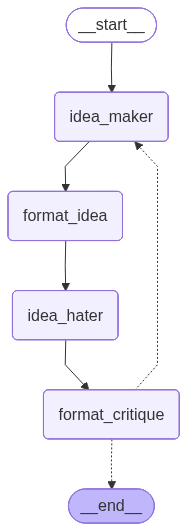

In [12]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Logging — write every LLM response to a JSON Lines file as it arrives

Instead of buffering the run trace in state, we install a **LangChain callback handler** at invocation time. Callbacks propagate automatically into every child run — including the `with_structured_output` calls inside the formatters — so the logger captures everything without any per-node plumbing.

Each LLM response is appended (with `flush()`) to a `.jsonl` file the instant it lands, and a one-line preview is printed to stdout. JSONL = one self-contained JSON object per line — append-friendly, streaming-friendly, trivially `jq`-able.

This is also the protocol shape an autonomous backend would use: instead of writing to a file, point the same handler at a WebSocket / pubsub / database.

In [13]:
import json, time
from pathlib import Path
from langchain_core.callbacks import BaseCallbackHandler

class JsonlLLMLogger(BaseCallbackHandler):
    """Append one JSON line per LLM response. Also prints a short preview."""

    def __init__(self, path, verbose: bool = True):
        self.path = Path(path)
        self.path.write_text("")          # truncate per run
        self.verbose = verbose
        self._pending: dict[str, dict] = {}

    def _write(self, entry: dict) -> None:
        with self.path.open("a") as f:
            f.write(json.dumps(entry, default=str) + "\n")
            f.flush()
        if self.verbose:
            tags = ",".join(entry.get("tags") or []) or "?"
            preview = (entry.get("output", [""])[0] or "").replace("\n", " ")[:120]
            print(f"[{tags}] {preview}{'…' if len(preview) == 120 else ''}")

    # Fires when a chat model call begins. We stash inputs keyed by run_id
    # so we can pair them with the on_llm_end event below.
    def on_chat_model_start(self, serialized, messages, *, run_id,
                            tags=None, metadata=None, **kwargs) -> None:
        flat = []
        for batch in messages:
            for m in batch:
                flat.append({"type": type(m).__name__, "content": getattr(m, "content", "")})
        self._pending[str(run_id)] = {
            "tags": list(tags or []),
            "model": (serialized or {}).get("kwargs", {}).get("model"),
            "messages": flat,
        }

    def on_llm_end(self, response, *, run_id, **kwargs) -> None:
        rid = str(run_id)
        inp = self._pending.pop(rid, {})
        outputs = []
        for batch in response.generations:
            for gen in batch:
                outputs.append(getattr(gen, "text", "") or "")
        usage = (response.llm_output or {}).get("token_usage")
        self._write({
            "ts": time.time(),
            "run_id": rid,
            "tags": inp.get("tags", []),
            "model": inp.get("model"),
            "input": inp.get("messages", []),
            "output": outputs,
            "usage": usage,
        })

## Run it

Empty initial state (`{}`), a run-scoped `IdeaContext`, and the logger attached via `config={"callbacks": [...]}`. None of the topic, rounds, or constraints appear in the graph — they live in the context.

In [15]:
LOG_PATH = "lab3_llm_log.jsonl"
logger = JsonlLLMLogger(LOG_PATH)

ctx = IdeaContext(
    research_topic=(
        "CMB lensing reconstruction from a single Planck-like temperature map. "
        "We have only the map; no external catalogs."
    ),
    num_rounds=2,
    constraints="No external data. The idea must be testable on the map alone.",
)

result = graph.invoke({}, context=ctx, config={"callbacks": [logger]})

[seq:step:1,idea_maker] **Title:** Self-Consistent Blind Source Separation for Iterative Lensing Reconstruction  **Summary:** This research prop…
[seq:step:1,format_idea] {   "title": "Self-Consistent Blind Source Separation for Iterative Lensing Reconstruction",   "summary": "This research…
[seq:step:1,idea_hater] This proposal is essentially a fresh coat of paint on a twenty-year-old house. Let's get straight to the point regarding…
[seq:step:1,format_critique] {   "feasibility": "The proposal faces significant challenges because iterative MAP estimation provides only marginal ga…
[seq:step:1,idea_maker] - title (str): Bias-Hardened Reconstruction via Non-Gaussian Gradient Templates for Temperature-Only Lensing.  - summary…
[seq:step:1,format_idea] {   "title": "Bias-Hardened Reconstruction via Non-Gaussian Gradient Templates for Temperature-Only Lensing",   "summary…
[seq:step:1,idea_hater] This proposal attempts to tackle a well-known issue in CMB lensing—foreground contamination—b

## The payoff — same graph, new context

The graph object is unchanged. To run on a completely different problem, we only swap the `IdeaContext`. This is the architectural difference from cmbagent's YAML approach: there, prompt templates are bound to the agent definitions; here, prompts read context at runtime, and a single compiled graph generalizes.

In [ ]:
ctx2 = IdeaContext(
    research_topic=(
        "A weekend side-project that teaches LangGraph fundamentals to a Python engineer "
        "who has never used it before."
    ),
    num_rounds=3,
    constraints=(
        "Must be buildable in under 6 hours. No paid APIs beyond a single LLM key. "
        "The idea must produce something the learner can demo."
    ),
)

logger2 = JsonlLLMLogger("lab3_llm_log_side_project.jsonl")
result2 = graph.invoke({}, context=ctx2, config={"callbacks": [logger2]})
result2["current_idea"]